
# Tooling 08: Live Demo Comparison And Choice Evidence

Corpus anchors: `QRE2`, `QRE4`, `LBM14`, `CAR7`, `IO4`, `IO5`, `IO7`, `IO8`, `PRIM14`, `PRIM15`, `PRIM16`.

This notebook runs the installed tooling-atlas demos from the correct environments and turns the outputs into a supervisor-facing comparison. It is deliberately layered: classical operator validation first, symbolic/logical resource modeling second, circuit/compiler/QEC tooling only after we have a small object to inspect.

The demos are evidence checks, not QCFD resource claims. A tool earns a stronger role only after the route note fixes the benchmark, encoding, loading/reloading, observable/readout, and resource gates.



## The Object We Reuse

The common object is a tiny periodic shifted-D2Q9/QRE2-style learning route:

$$
 g_{t+1} = S\left[(I + F_1)g_t + F_2(g_t \otimes g_t)\right].
$$

For this notebook, `SciPy` validates the sparse classical operator, `Bartiq/QREF` aggregates placeholder symbolic resources, `qlbm` builds a QLBM-family circuit object, `Qualtran` inspects logical bloq/call-graph abstractions, `Qiskit/Cirq/PennyLane/PyZX` inspect tiny circuit objects, and `Azure QDK` converts toy logical counts into physical-resource intuition.


In [1]:

from __future__ import annotations

import base64
import json
import os
import shutil
import subprocess
import sys
import textwrap
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
CACHE = ROOT / '.cache' / 'tooling_atlas'
SCRIPT_DIR = CACHE / 'live_demo_scripts'
RESULT_PATH = CACHE / 'live_demo_results.json'
SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = CACHE / 'installed_packages_report.json'
if REPORT_PATH.exists():
    installed_report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
else:
    installed_report = {}

print(f'workspace: {ROOT}')
print(f'installed report present: {REPORT_PATH.exists()}')


workspace: C:\Users\NishchayVORA\Documents\PQ_CFD
installed report present: True


In [2]:

def python_for(env_name: str) -> str | None:
    entry = installed_report.get(env_name, {})
    candidate = entry.get('python')
    if candidate and Path(candidate).exists():
        return candidate
    return None


def _parse_demo_json(stdout: str) -> dict:
    prefix = 'DEMO_JSON:'
    for line in reversed(stdout.splitlines()):
        if line.startswith(prefix):
            return json.loads(line[len(prefix):])
    raise ValueError('demo did not emit DEMO_JSON line')


def run_python_demo(name: str, python_exe: str | None, source: str, *, timeout: int = 180) -> dict:
    if not python_exe:
        return {
            'status': 'blocked',
            'reason': 'Python environment for this sandbox is not available.',
        }

    script_path = SCRIPT_DIR / f'{name}.py'
    script_path.write_text(source, encoding='utf-8')
    env = os.environ.copy()
    src_path = str(ROOT / 'src')
    env['PYTHONPATH'] = src_path + os.pathsep + env.get('PYTHONPATH', '')
    completed = subprocess.run(
        [python_exe, str(script_path)],
        cwd=str(ROOT),
        env=env,
        text=True,
        capture_output=True,
        timeout=timeout,
    )
    result = {
        'status': 'passed' if completed.returncode == 0 else 'failed',
        'returncode': completed.returncode,
        'stdout_tail': completed.stdout[-2000:],
        'stderr_tail': completed.stderr[-2000:],
        'python': python_exe,
    }
    if completed.returncode == 0:
        try:
            result['output'] = _parse_demo_json(completed.stdout)
        except Exception as exc:
            result['status'] = 'failed'
            result['parse_error'] = f'{type(exc).__name__}: {exc}'
    return result


def run_wsl_python_demo(name: str, source: str, *, timeout: int = 180) -> dict:
    if not shutil.which('wsl.exe'):
        return {'status': 'blocked', 'reason': 'wsl.exe is not available from this Windows session.'}
    encoded = base64.b64encode(source.encode('utf-8')).decode('ascii')
    command = (
        "cd ~/PQ_CFD && "
        "PYTHONPATH=src .cache/psiqdk-uv-venv/bin/python -c "
        + json.dumps("import base64; exec(base64.b64decode('" + encoded + "').decode('utf-8'))")
    )
    completed = subprocess.run(
        ['wsl.exe', 'bash', '-lc', command],
        cwd=str(ROOT),
        text=True,
        capture_output=True,
        timeout=timeout,
    )
    result = {
        'status': 'passed' if completed.returncode == 0 else 'failed',
        'returncode': completed.returncode,
        'stdout_tail': completed.stdout[-2000:],
        'stderr_tail': completed.stderr[-2000:],
        'python': 'WSL ~/PQ_CFD/.cache/psiqdk-uv-venv/bin/python',
    }
    if completed.returncode == 0:
        try:
            result['output'] = _parse_demo_json(completed.stdout)
        except Exception as exc:
            result['status'] = 'failed'
            result['parse_error'] = f'{type(exc).__name__}: {exc}'
    return result


In [3]:

PROMOTED_CORE_SOURCE = r'''
import json
from importlib.metadata import version

import numpy as np

from pq_cfd import _qre2_shifted as dense
from pq_cfd._bartiq_qref_resources import evaluate_qre2_taylor_green_route
from pq_cfd._qre2_sparse import (
    build_sparse_shifted_collision_terms,
    build_sparse_streaming_matrix,
    step_shifted_sparse,
)

shape = (2, 2)
tau = 0.8
rng = np.random.default_rng(7)
g = rng.normal(scale=1e-3, size=(9, *shape))
g_vector = dense.flatten_site_major(g)
streaming_dense = dense.build_streaming_matrix(shape)
f1_dense, f2_dense = dense.build_shifted_collision_terms(tau, shape)
streaming_sparse = build_sparse_streaming_matrix(shape)
f1_sparse, f2_sparse = build_sparse_shifted_collision_terms(tau, shape)
next_dense = dense.step_shifted_matrix(g_vector, streaming_dense, f1_dense, f2_dense)
next_sparse = step_shifted_sparse(g_vector, streaming_sparse, f1_sparse, f2_sparse)
max_abs_diff = float(np.max(np.abs(next_dense - next_sparse)))

assignments = {
    'N_x': 4, 'N_y': 4, 'N_t': 10, 'N_samples': 100,
    'q_site': 4, 'q_velocity': 4, 'q_population': 8, 'q_work': 12, 'q_observable': 3,
    'T_load': 1000, 'T_stream': 200, 'T_collide': 3000, 'T_success': 500,
    'T_readout_sample': 2, 'p_load': 0.9, 'p_step': 0.99, 'p_readout': 0.95,
}
routine = evaluate_qre2_taylor_green_route(assignments)
resources = {}
for key, resource in routine.resources.items():
    value = resource.value
    if hasattr(value, 'item'):
        value = value.item()
    resources[key] = value

result = {
    'versions': {pkg: version(pkg) for pkg in ['numpy', 'scipy', 'bartiq', 'qref']},
    'sparse_operator': {
        'shape': list(streaming_sparse.shape),
        'streaming_nnz': int(streaming_sparse.nnz),
        'f1_nnz': int(f1_sparse.nnz),
        'f2_nnz': int(f2_sparse.nnz),
        'streaming_density': float(streaming_sparse.nnz / (streaming_sparse.shape[0] * streaming_sparse.shape[1])),
        'max_abs_diff_sparse_vs_dense': max_abs_diff,
        'check_passed': bool(max_abs_diff < 1e-12),
    },
    'bartiq_qref_placeholder_resources': resources,
    'interpretation': 'Use now for classical operator checks and private symbolic route bookkeeping; this is not a circuit/resource claim.',
}
print('DEMO_JSON:' + json.dumps(result, sort_keys=True))
'''

PSIQUANTUM_WSL_SOURCE = r'''
import io
import json
from contextlib import redirect_stdout
from importlib.metadata import PackageNotFoundError, version

packages = ['psiqdk', 'psiqdk-workbench', 'psiqdk-algorithms', 'psiqdk-visualize', 'bartiq', 'qref']
versions = {}
for package in packages:
    try:
        versions[package] = version(package)
    except PackageNotFoundError:
        versions[package] = None

output = {'versions': versions}
try:
    from psiqdk.workbench import QPU, Qubits
    qpu = QPU(num_qubits=2, filters=['>>buffer>>'])
    reg = Qubits(2, 'reg', qpu=qpu)
    reg[0].had()
    reg[1].x(cond=reg[0])
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        qpu.print_instructions(format='asm')
    output['workbench_demo'] = {
        'status': 'passed',
        'instructions': [line.strip() for line in buffer.getvalue().splitlines() if line.strip()],
    }
except Exception as exc:
    output['workbench_demo'] = {'status': 'failed', 'error': f'{type(exc).__name__}: {exc}'}

output['interpretation'] = 'PsiQDK is the Python/Workbench route into PsiQuantum-native experiments; Construct is the broader cloud platform, not a pip dependency we should promote blindly.'
print('DEMO_JSON:' + json.dumps(output, sort_keys=True))
'''

QLBM_SOURCE = r'''
import json
from importlib.metadata import version

from qlbm.components.collisionless import CQLBM
from qlbm.components.spacetime import SpaceTimeQLBM
from qlbm.lattice import CollisionlessLattice, SpaceTimeLattice

collisionless_lattice = CollisionlessLattice({
    'lattice': {'dim': {'x': 8, 'y': 8}, 'velocities': {'x': 4, 'y': 4}},
    'geometry': [],
})
collisionless_algorithm = CQLBM(collisionless_lattice)
spacetime_lattice = SpaceTimeLattice(
    num_timesteps=1,
    lattice_data={'lattice': {'dim': {'x': 4, 'y': 8}, 'velocities': 'D2Q4'}, 'geometry': []},
)
spacetime_algorithm = SpaceTimeQLBM(spacetime_lattice)

result = {
    'versions': {pkg: version(pkg) for pkg in ['qlbm', 'qiskit', 'pytket', 'qulacs']},
    'collisionless_cqlbm': {
        'num_total_qubits': int(collisionless_lattice.num_total_qubits),
        'num_grid_qubits': int(collisionless_lattice.num_grid_qubits),
        'num_velocity_qubits': int(collisionless_lattice.num_velocity_qubits),
        'num_ancilla_qubits': int(collisionless_lattice.num_ancilla_qubits),
        'circuit_qubits': int(collisionless_algorithm.circuit.num_qubits),
        'circuit_size': int(collisionless_algorithm.circuit.size()),
        'count_ops': {str(k): int(v) for k, v in collisionless_algorithm.circuit.count_ops().items()},
    },
    'spacetime_d2q4_one_step': {
        'num_total_qubits': int(spacetime_lattice.num_total_qubits),
        'circuit_qubits': int(spacetime_algorithm.circuit.num_qubits),
        'circuit_size': int(spacetime_algorithm.circuit.size()),
        'count_ops': {str(k): int(v) for k, v in spacetime_algorithm.circuit.count_ops().items()},
    },
    'interpretation': 'qlbm is the strongest live domain-specific circuit comparator, but its demonstrated assumptions are not the same as the current shifted-D2Q9/QRE2 route.',
}
print('DEMO_JSON:' + json.dumps(result, sort_keys=True))
'''

QUALTRAN_SOURCE = r'''
import json
from importlib.metadata import version

from qualtran.bloqs.basic_gates import CNOT, Hadamard, TGate, Toffoli

bloqs = [Toffoli(), TGate(), Hadamard(), CNOT()]
summaries = {}
for bloq in bloqs:
    entry = {'signature': str(bloq.signature)}
    try:
        call_graph = bloq.call_graph()
        counts = call_graph[1] if isinstance(call_graph, tuple) else call_graph
        entry['call_graph_counts'] = {str(k): int(v) for k, v in counts.items()}
    except Exception as exc:
        entry['call_graph_error'] = f'{type(exc).__name__}: {exc}'
    summaries[type(bloq).__name__] = entry

result = {
    'versions': {pkg: version(pkg) for pkg in ['qualtran', 'bartiq', 'qref']},
    'bloq_summaries': summaries,
    'interpretation': 'Qualtran is useful when we can express a QCFD primitive as a bloq/call graph; it does not choose the CFD encoding or observable for us.',
}
print('DEMO_JSON:' + json.dumps(result, sort_keys=True))
'''

GENERAL_CIRCUIT_SOURCE = r'''
import json
from collections import Counter
from importlib.metadata import version

import cirq
import numpy as np
import pennylane as qml
import pyzx as zx
import stim
from openfermion import QubitOperator
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
simulator = AerSimulator(seed_simulator=11)
qiskit_counts = simulator.run(transpile(qc, simulator), shots=256).result().get_counts()

q0, q1 = cirq.LineQubit.range(2)
cirq_circuit = cirq.Circuit(cirq.H(q0), cirq.CNOT(q0, q1), cirq.measure(q0, q1, key='m'))
cirq_result = cirq.Simulator(seed=11).run(cirq_circuit, repetitions=256)
cirq_counts = {str(key): int(value) for key, value in Counter(cirq_result.measurements['m'].dot([2, 1])).items()}

zx_circuit = zx.Circuit(2)
zx_circuit.add_gate('HAD', 0)
zx_circuit.add_gate('CNOT', 0, 1)
zx_graph = zx_circuit.to_graph()

dev = qml.device('default.qubit', wires=2)
@qml.qnode(dev)
def bell_probs():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])
probs = bell_probs()
resources = qml.specs(bell_probs)()['resources']

op = QubitOperator('X0 Y1', 0.5) + QubitOperator('Z0', -1.0)

result = {
    'versions': {pkg: version(pkg) for pkg in ['qiskit', 'qiskit-aer', 'cirq', 'pennylane', 'pyzx', 'stim', 'openfermion']},
    'qiskit_bell': {'count_ops': {str(k): int(v) for k, v in qc.count_ops().items()}, 'counts': {str(k): int(v) for k, v in qiskit_counts.items()}},
    'cirq_bell': {'moments': len(cirq_circuit), 'counts_decimal': cirq_counts},
    'pyzx_bell': {'vertices': int(zx_graph.num_vertices()), 'edges': int(zx_graph.num_edges()), 'stats': zx_circuit.stats().splitlines()[0]},
    'pennylane_bell': {'probs': [float(x) for x in probs], 'num_gates': int(resources.num_gates), 'depth': int(resources.depth), 'gate_types': dict(resources.gate_types)},
    'openfermion_toy_operator': {'term_count': len(op.terms), 'terms': {str(k): float(v.real) for k, v in op.terms.items()}},
    'interpretation': 'Circuit SDKs are excellent for teaching and tiny sanity checks; they are not resource estimators by themselves.',
}
print('DEMO_JSON:' + json.dumps(result, sort_keys=True))
'''

QEC_SOURCE = r'''
import importlib.util
import json
from importlib.metadata import PackageNotFoundError, version

import numpy as np
import pymatching
import stim

versions = {pkg: version(pkg) for pkg in ['stim', 'pymatching']}
if importlib.util.find_spec('sinter') is not None:
    try:
        versions['sinter'] = version('sinter')
    except PackageNotFoundError:
        versions['sinter'] = 'imported; distribution version not found'
else:
    versions['sinter'] = 'not installed in this sandbox; installed in env-watch for scout use'

circuit = stim.Circuit.generated(
    'repetition_code:memory',
    rounds=3,
    distance=3,
    before_round_data_depolarization=0.02,
)
dem = circuit.detector_error_model(decompose_errors=True)
matching = pymatching.Matching.from_detector_error_model(dem)
samples = circuit.compile_detector_sampler(seed=11).sample(200, append_observables=True)
detectors = samples[:, :dem.num_detectors]
observables = samples[:, dem.num_detectors:]
predictions = matching.decode_batch(detectors)
logical_error_rate = float(np.mean(predictions.reshape(observables.shape) != observables))

result = {
    'versions': versions,
    'repetition_code_demo': {
        'shots': int(samples.shape[0]),
        'num_detectors': int(dem.num_detectors),
        'num_observables': int(dem.num_observables),
        'logical_error_rate_sample': logical_error_rate,
    },
    'interpretation': 'Stim/PyMatching are live for QEC and decoder intuition; sinter is installed in the watch sandbox for later batch studies.',
}
print('DEMO_JSON:' + json.dumps(result, sort_keys=True))
'''

AZURE_QRE_SOURCE = r'''
import json
from importlib.metadata import version

from qsharp.estimator import LogicalCounts

logical_counts = {
    'numQubits': 47,
    'tCount': 47500,
    'rotationCount': 2000,
    'rotationDepth': 500,
    'cczCount': 0,
    'measurementCount': 1000,
}
result = LogicalCounts(logical_counts).estimate()
formatted = result['physicalCountsFormatted']
selected = {key: formatted[key] for key in [
    'physicalQubits',
    'runtime',
    'algorithmicLogicalQubits',
    'logicalDepth',
    'numTstates',
    'numTfactories',
    'physicalQubitsForAlgorithm',
    'physicalQubitsForTfactories',
    'requiredLogicalQubitErrorRate',
]}

output = {
    'versions': {pkg: version(pkg) for pkg in ['qdk', 'qsharp', 'qsharp-widgets']},
    'input_logical_counts': logical_counts,
    'selected_physical_estimate': selected,
    'status': result['status'],
    'interpretation': 'Azure QRE is strongest after logical counts exist; its output is sensitivity evidence, not proof that the logical counts are valid.',
}
print('DEMO_JSON:' + json.dumps(output, sort_keys=True))
'''

WATCH_SOURCE = r'''
import importlib
import json
from importlib.metadata import PackageNotFoundError, version

import numpy as np
from bqskit.ir import Circuit as BQSKitCircuit
from bqskit.ir.gates import CNOTGate, HGate
from fipy import CellVariable, DiffusionTerm, Grid1D, TransientTerm
import jax
import jax.numpy as jnp
from pytket import Circuit as TKCircuit

watch_modules = {
    'pytket': 'pytket',
    'bqskit': 'bqskit',
    'mqt-qmap': 'mqt.qmap',
    'pyLIQTR': 'pyLIQTR',
    'qrisp': 'qrisp',
    'classiq': 'classiq',
    'qamomile': 'qamomile',
    'quri-parts': 'quri_parts',
    'jax': 'jax',
    'fipy': 'fipy',
    'sinter': 'sinter',
}
imports = {}
for package, module in watch_modules.items():
    try:
        importlib.import_module(module)
        try:
            package_version = version(package)
        except PackageNotFoundError:
            package_version = 'imported; distribution version not found'
        imports[package] = {'import_ok': True, 'version': package_version}
    except Exception as exc:
        imports[package] = {'import_ok': False, 'error': f'{type(exc).__name__}: {exc}'}

tk = TKCircuit(2, 2).H(0).CX(0, 1).Measure(0, 0).Measure(1, 1)
bq = BQSKitCircuit(2)
bq.append_gate(HGate(), [0])
bq.append_gate(CNOTGate(), [0, 1])

grad_value = float(jax.grad(lambda x: jnp.sin(x) + x * x)(1.0))
mesh = Grid1D(nx=8, dx=1.0)
field = CellVariable(mesh=mesh, value=0.0)
field.setValue(1.0, where=mesh.cellCenters[0] < 4)
(TransientTerm() == DiffusionTerm(coeff=1.0)).solve(var=field, dt=0.1)

result = {
    'imports': imports,
    'pytket_bell': {'n_qubits': int(tk.n_qubits), 'n_gates': int(tk.n_gates)},
    'bqskit_bell': {'num_qudits': int(bq.num_qudits), 'num_operations': int(bq.num_operations), 'gate_counts': {str(k): int(v) for k, v in bq.gate_counts.items()}},
    'jax_grad_check': {'d_dx_sin_x_plus_x2_at_1': grad_value},
    'fipy_diffusion_check': {'cells': int(mesh.numberOfCells), 'mean_after_step': float(np.mean(field.value))},
    'interpretation': 'These are scout tools: useful for compilation, optimization, DSL, or classical PDE experiments after a route need is explicit.',
}
print('DEMO_JSON:' + json.dumps(result, sort_keys=True))
'''

In [4]:

demos = {
    'promoted_core_scipy_bartiq_qref': lambda: run_python_demo('promoted_core_scipy_bartiq_qref', sys.executable, PROMOTED_CORE_SOURCE, timeout=120),
    'psiquantum_wsl_psiqdk_workbench': lambda: run_wsl_python_demo('psiquantum_wsl_psiqdk_workbench', PSIQUANTUM_WSL_SOURCE, timeout=180),
    'qcfd_domain_qlbm': lambda: run_python_demo('qcfd_domain_qlbm', python_for('env-logical'), QLBM_SOURCE, timeout=240),
    'logical_models_qualtran': lambda: run_python_demo('logical_models_qualtran', python_for('env-qualtran'), QUALTRAN_SOURCE, timeout=180),
    'circuits_general_stack': lambda: run_python_demo('circuits_general_stack', python_for('env-general'), GENERAL_CIRCUIT_SOURCE, timeout=240),
    'physical_qec_stim_pymatching': lambda: run_python_demo('physical_qec_stim_pymatching', python_for('env-general'), QEC_SOURCE, timeout=180),
    'azure_qdk_qre': lambda: run_python_demo('azure_qdk_qre', python_for('env-azure'), AZURE_QRE_SOURCE, timeout=240),
    'compiler_and_watch_stack': lambda: run_python_demo('compiler_and_watch_stack', python_for('env-watch'), WATCH_SOURCE, timeout=240),
}

live_results = {
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'workspace': str(ROOT),
    'installed_report_path': str(REPORT_PATH),
    'demos': {},
}

for demo_name, runner in demos.items():
    print(f'Running {demo_name} ...')
    try:
        live_results['demos'][demo_name] = runner()
    except subprocess.TimeoutExpired as exc:
        live_results['demos'][demo_name] = {'status': 'failed', 'reason': f'timeout after {exc.timeout} seconds'}
    except Exception as exc:
        live_results['demos'][demo_name] = {'status': 'failed', 'reason': f'{type(exc).__name__}: {exc}'}
    print(f"  -> {live_results['demos'][demo_name]['status']}")

blocked_packages = []
for env_name, env_info in installed_report.items():
    for package, info in env_info.get('packages', {}).items():
        if not info.get('import_ok', False):
            blocked_packages.append({
                'environment': env_name,
                'package': package,
                'version': info.get('version'),
                'error': info.get('error'),
            })
live_results['blocked_packages_from_install_report'] = blocked_packages

RESULT_PATH.write_text(json.dumps(live_results, indent=2, sort_keys=True), encoding='utf-8')
print(f'wrote {RESULT_PATH}')


Running promoted_core_scipy_bartiq_qref ...


  -> passed
Running psiquantum_wsl_psiqdk_workbench ...


  -> passed
Running qcfd_domain_qlbm ...


  -> passed
Running logical_models_qualtran ...


  -> passed
Running circuits_general_stack ...


  -> passed
Running physical_qec_stim_pymatching ...


  -> passed
Running azure_qdk_qre ...


  -> passed
Running compiler_and_watch_stack ...


  -> passed
wrote C:\Users\NishchayVORA\Documents\PQ_CFD\.cache\tooling_atlas\live_demo_results.json


In [5]:

summary_rows = []
for name, result in live_results['demos'].items():
    output = result.get('output', {})
    summary_rows.append({
        'demo': name,
        'status': result.get('status'),
        'versions': ', '.join(f"{k} {v}" for k, v in output.get('versions', {}).items())[:140],
        'interpretation': output.get('interpretation', result.get('reason', '')),
    })

for row in summary_rows:
    print(f"{row['demo']:34s} {row['status']:8s} {row['versions']}")
    print(f"  {row['interpretation']}")

if live_results['blocked_packages_from_install_report']:
    print('\nBlocked or not importable in sandbox report:')
    for item in live_results['blocked_packages_from_install_report']:
        print(f"- {item['package']} ({item['environment']}): {item['error']}")


promoted_core_scipy_bartiq_qref    passed   bartiq 0.17.0, numpy 2.4.6, qref 0.11.0, scipy 1.17.1
  Use now for classical operator checks and private symbolic route bookkeeping; this is not a circuit/resource claim.
psiquantum_wsl_psiqdk_workbench    passed   bartiq 0.17.0, psiqdk 2.0.0, psiqdk-algorithms 1.22.3, psiqdk-visualize 0.97.2, psiqdk-workbench 4.45.0, qref 0.11.0
  PsiQDK is the Python/Workbench route into PsiQuantum-native experiments; Construct is the broader cloud platform, not a pip dependency we should promote blindly.
qcfd_domain_qlbm                   passed   pytket 2.18.0, qiskit 2.4.1, qlbm 0.0.6, qulacs 0.6.13
  qlbm is the strongest live domain-specific circuit comparator, but its demonstrated assumptions are not the same as the current shifted-D2Q9/QRE2 route.
logical_models_qualtran            passed   bartiq 0.12.1, qref 0.11.0, qualtran 0.7.0
  Qualtran is useful when we can express a QCFD primitive as a bloq/call graph; it does not choose the CFD encoding or

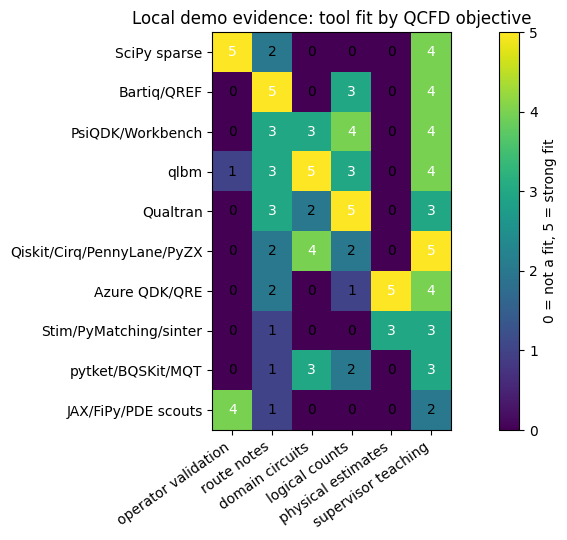

In [6]:

objective_scores = {
    'SciPy sparse': {'operator validation': 5, 'route notes': 2, 'domain circuits': 0, 'logical counts': 0, 'physical estimates': 0, 'supervisor teaching': 4},
    'Bartiq/QREF': {'operator validation': 0, 'route notes': 5, 'domain circuits': 0, 'logical counts': 3, 'physical estimates': 0, 'supervisor teaching': 4},
    'PsiQDK/Workbench': {'operator validation': 0, 'route notes': 3, 'domain circuits': 3, 'logical counts': 4, 'physical estimates': 0, 'supervisor teaching': 4},
    'qlbm': {'operator validation': 1, 'route notes': 3, 'domain circuits': 5, 'logical counts': 3, 'physical estimates': 0, 'supervisor teaching': 4},
    'Qualtran': {'operator validation': 0, 'route notes': 3, 'domain circuits': 2, 'logical counts': 5, 'physical estimates': 0, 'supervisor teaching': 3},
    'Qiskit/Cirq/PennyLane/PyZX': {'operator validation': 0, 'route notes': 2, 'domain circuits': 4, 'logical counts': 2, 'physical estimates': 0, 'supervisor teaching': 5},
    'Azure QDK/QRE': {'operator validation': 0, 'route notes': 2, 'domain circuits': 0, 'logical counts': 1, 'physical estimates': 5, 'supervisor teaching': 4},
    'Stim/PyMatching/sinter': {'operator validation': 0, 'route notes': 1, 'domain circuits': 0, 'logical counts': 0, 'physical estimates': 3, 'supervisor teaching': 3},
    'pytket/BQSKit/MQT': {'operator validation': 0, 'route notes': 1, 'domain circuits': 3, 'logical counts': 2, 'physical estimates': 0, 'supervisor teaching': 3},
    'JAX/FiPy/PDE scouts': {'operator validation': 4, 'route notes': 1, 'domain circuits': 0, 'logical counts': 0, 'physical estimates': 0, 'supervisor teaching': 2},
}
objectives = list(next(iter(objective_scores.values())).keys())
tools = list(objective_scores.keys())
score_matrix = np.array([[objective_scores[tool][objective] for objective in objectives] for tool in tools])

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(score_matrix, cmap='viridis', vmin=0, vmax=5)
ax.set_xticks(range(len(objectives)), labels=objectives, rotation=35, ha='right')
ax.set_yticks(range(len(tools)), labels=tools)
for i in range(len(tools)):
    for j in range(len(objectives)):
        ax.text(j, i, score_matrix[i, j], ha='center', va='center', color='white' if score_matrix[i, j] >= 3 else 'black')
ax.set_title('Local demo evidence: tool fit by QCFD objective')
fig.colorbar(im, ax=ax, label='0 = not a fit, 5 = strong fit')
fig.tight_layout()
plt.show()



## Analysis: What To Choose For What

Use **NumPy/SciPy sparse** as the default backbone for QCFD operator validation. The live check compares dense and sparse shifted-D2Q9/QRE2-style updates on the same tiny operator and requires agreement to numerical precision. This is the strongest current evidence because it tests the actual mathematical object before any quantum package enters the story.

Use **QREF + Bartiq** now for route-note bookkeeping. The live demo validates a QREF-style resource tree and evaluates symbolic placeholder counts. It is valuable because it forces us to name boxes such as loading, streaming, collision, success control, and observable readout. It cannot justify any T-count formula until each box has a real encoding and primitive implementation.

Use **PsiQDK/Workbench** as a PsiQuantum-native sandbox, preferably through WSL or Construct when cloud/platform features are needed. Construct is the broader platform; PsiQDK is the Python/Workbench SDK layer; Bartiq/QREF are schema and symbolic aggregation layers. We should not install/promote a whole umbrella into the maintained project because platform access, Linux/runtime constraints, and route assumptions are separate decisions.

Use **qlbm** as the strongest live QLBM-family comparator. It can build domain-specific LBM circuits and expose qubit/register/gate structure. It should be compared against `QRE2/QRE4`, not treated as the same route, because its demonstrated collisionless and space-time assumptions differ from the current shifted-D2Q9 benchmark route.

Use **Qualtran** when we are ready to represent a specific QCFD primitive as an operation-level logical model. It is strong for bloq/call-graph thinking, but it does not decide the CFD encoding, data loading, reloading, observable, or benchmark.

Use **Qiskit/Cirq/PennyLane/PyZX/pytket/BQSKit/MQT** for teaching, circuit sanity checks, decomposition, optimization, and compiler comparisons. They become decision-relevant only after we have a meaningful primitive circuit. A Bell circuit demo proves API availability and comparison vocabulary, not QCFD feasibility.

Use **Azure QDK/QRE** after logical counts exist. The live demo shows how toy logical counts become physical qubits, runtime, T-factory counts, and error-rate requirements. It is excellent for sensitivity analysis, but it cannot validate the logical counts it receives.

Use **Stim/PyMatching/sinter** for QEC/decoder intuition and later surface-code sanity checks. They are not a full application-level physical resource estimator.



## What This Cannot Prove

This notebook cannot prove quantum advantage, QCFD feasibility, or a promoted resource estimate. It also cannot prove that full-field readout is acceptable; full-field readout remains a negative-control baseline unless a route paper justifies it. The next promotion gate is still a route note that fixes the benchmark observable, encoding, loading/reloading model, readout model, primitive decomposition, and comparison target papers.

Supervisor summary: we should not choose one quantum software stack for everything. The evidence supports a layered workflow: validate CFD operators classically with NumPy/SciPy; express route boxes and symbolic resources with QREF/Bartiq; use PsiQDK/Workbench for PsiQuantum-native primitive trials; use qlbm as a QLBM-family comparator; use Qualtran for operation-level logical models; and use Azure QDK only after logical counts exist to study physical-resource sensitivity.
